In [7]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import *
from sklearn.preprocessing import *
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import *
from sklearn.model_selection import *
from sklearn.metrics import *
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df=pd.read_csv(r"C:\Users\USER\OneDrive\سطح المكتب\hypertension_dataset.csv")
df

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NnMedicine,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NnMedicine,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NnMedicine,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No
...,...,...,...,...,...,...,...,...,...,...,...
1980,56,10.2,0,Normal,6.5,25.0,Diuretic,Yes,Low,Non-Smoker,Yes
1981,29,8.9,4,Hypertension,6.9,16.9,NnMedicine,Yes,High,Non-Smoker,Yes
1982,64,5.9,9,Normal,5.6,18.9,ACE Inhibitor,Yes,Moderate,Non-Smoker,Yes
1983,35,7.4,8,Prehypertension,8.2,29.2,NnMedicine,Yes,Moderate,Non-Smoker,No


In [9]:
df.duplicated().sum()

0

In [10]:
df.isnull().sum()

Age                 0
Salt_Intake         0
Stress_Score        0
BP_History          0
Sleep_Duration      0
BMI                 0
Medication          0
Family_History      0
Exercise_Level      0
Smoking_Status      0
Has_Hypertension    0
dtype: int64

In [11]:
df.describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


In [12]:
df['Medication'].nunique()


5

In [13]:
encoder = LabelEncoder()
df['Has_Hypertension_encoded'] = encoder.fit_transform(df['Has_Hypertension'])
print(encoder.classes_)

['No' 'Yes']


In [14]:
encoder = LabelEncoder()
df['medicine_encoded'] = encoder.fit_transform(df['Medication'])
print(encoder.classes_)

['ACE Inhibitor' 'Beta Blocker' 'Diuretic' 'NnMedicine' 'Other']


In [15]:
encoder = LabelEncoder()
df['BP_History_encoded'] = encoder.fit_transform(df['BP_History'])
print(encoder.classes_)


['Hypertension' 'Normal' 'Prehypertension']


In [16]:
encoder = LabelEncoder()
df['Family_History_encoded'] = encoder.fit_transform(df['Family_History'])
print(encoder.classes_)


['No' 'Yes']


In [17]:
encoder = LabelEncoder()
df['Exercise_Level_encoded'] = encoder.fit_transform(df['Exercise_Level'])
print(encoder.classes_)


['High' 'Low' 'Moderate']


In [18]:
encoder = LabelEncoder()
df['Smoking_Status_encoded'] = encoder.fit_transform(df['Smoking_Status'])
print(encoder.classes_)

['Non-Smoker' 'Smoker']


In [19]:
y = df['Has_Hypertension']
X = df[['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI',
        'medicine_encoded', 'BP_History_encoded', 'Family_History_encoded',
        'Exercise_Level_encoded', 'Smoking_Status_encoded']]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [21]:
model = RandomForestClassifier(n_estimators=90, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=90, random_state=42)

In [22]:

scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')


In [23]:
print(f"All cross-validation scores: {scores}")
print(f"Mean cross-validation score: {np.mean(scores):.4f}")

All cross-validation scores: [0.96482412 0.96482412 0.95477387 0.96984925 0.9798995  0.97474747
 0.97979798 0.96464646 0.97979798 0.97979798]
Mean cross-validation score: 0.9713


In [24]:
y_pred = model.predict(X_test)


In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.959758551307847
              precision    recall  f1-score   support

          No       0.95      0.97      0.96       238
         Yes       0.97      0.95      0.96       259

    accuracy                           0.96       497
   macro avg       0.96      0.96      0.96       497
weighted avg       0.96      0.96      0.96       497



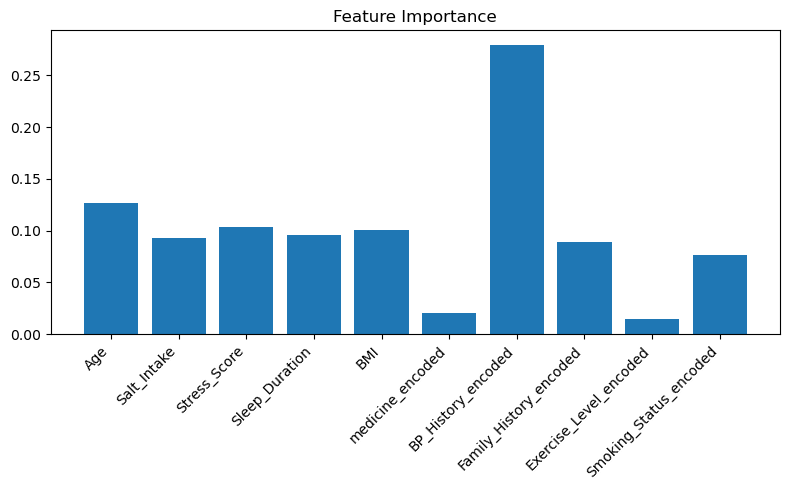

In [26]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)), features, rotation=45, ha="right")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

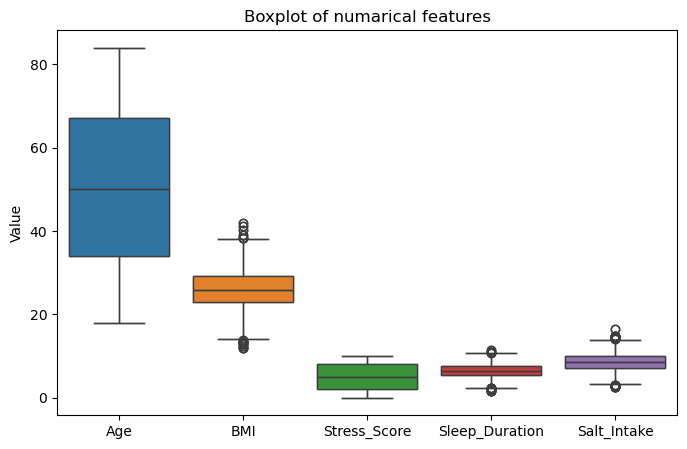

In [27]:
data = df[["Age", "BMI","Stress_Score","Sleep_Duration","Salt_Intake"]]
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["Age", "BMI","Stress_Score","Sleep_Duration","Salt_Intake"]])
sns.boxplot(data=data)
plt.title("Boxplot of numarical features")
plt.ylabel("Value")
plt.show()


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[231   7]
 [ 13 246]]


In [56]:
TP,FP,FN = 246,7,13

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * precision * recall / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Precision: 0.9723320158102767
Recall: 0.9498069498069498
F1 Score: 0.9609375
